# FDPIS — Notebook 5: Layer 3 + Layer 4 Integration

**Inputs:** `data/processed.parquet`, models in `results/layer4/`.

### The problem this fixes
Notebook 4 showed the cascade chain decaying while reality did not:

| Depth | Mean predicted | Mean actual |
|---|---|---|
| 1 | 34.6 | 27.4 |
| 3 | 14.6 | 31.5 |
| 5 | 9.0 | 39.6 |

The chain assumed the inherited delay is the *only* delay on each downstream leg. In reality a
downstream flight also picks up its **own fresh primary delay** — late crew, mechanical issue,
congestion — stacked on top of what it inherited. Modelling only inheritance produces geometric
decay; modelling both produces accumulation.

### The fix
```
total_delay(n+1) = propagated(n+1)      +  expected_primary(n+1)
                    ↑ Layer 4               ↑ Layer 3
```

### The important distinction
Primary delay enters the **chain** — the aircraft genuinely arrives late by the *total* amount,
so that is what the next hop inherits.

It does **not** enter the propagation target. `LATE_AIRCRAFT_DELAY` measures only the inherited
component, so the propagated prediction is still scored against it. A second evaluation scores
*total* predicted delay against *total* actual delay — which is what an operations controller
actually cares about.

## 1 — Setup

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import json, os
from sklearn.metrics import mean_absolute_error

pd.set_option('display.max_columns', 80)

df = pd.read_parquet('data/processed.parquet')

with open('results/layer4/config.json') as f:
    cfg = json.load(f)
PROP_FEATURES  = cfg['features']
CAT_COLS       = cfg['cat_cols']
GATE_THRESHOLD = cfg['gate_threshold']

gate = xgb.XGBClassifier(); gate.load_model('results/layer4/xgb_gate.json')
mag = {}
for n in ['lower','median','upper']:
    m = xgb.XGBRegressor(); m.load_model(f'results/layer4/xgb_hurdle_{n}.json')
    mag[n] = m

dates = np.sort(df['FL_DATE'].unique())
train_end = dates[int(len(dates)*0.70)]
val_end   = dates[int(len(dates)*0.85)]
train = df[df['FL_DATE'] <= train_end]
test  = df[df['FL_DATE'] > val_end].copy()

test = test.sort_values(['TAIL_NUM','FL_DATE','LEG_NUM']).reset_index(drop=True)
test['ROT_ID'] = test['TAIL_NUM'].astype(str) + '_' + test['FL_DATE'].dt.strftime('%Y%m%d')
print(f'Train {len(train):,} | Test {len(test):,} | Rotations {test["ROT_ID"].nunique():,}')

Train 1,176,905 | Test 262,171 | Rotations 63,102


## 2 — Expected primary delay (the Layer 3 contribution)

Layer 3 outputs a *probability* of delay, not minutes. Notebook 2 established that per-flight
magnitude is not predictable from schedule data — the regressor beat a constant by 0.1 minutes.

So instead of predicting magnitude per flight, we use an **empirical expectation**: given this
airport, this hour and this carrier, what is the *average* primary delay historically? That is a
calibration, not a magnitude model, and it does not repeat the failed experiment.

This uses the same signal that dominated Layer 3's feature importance — `ENC_ROUTE` at 18.6%
and `ENC_ORIGIN_HOUR` at 14.0%, together a third of the model — without needing to rebuild
Layer 3's full train-fitted encoding pipeline.

**Computed on training data only.**

In [16]:
tr = train.copy()
# Primary delay = departure delay NOT attributed to a late incoming aircraft
tr['PRIMARY_DELAY'] = np.where(
    tr['LATE_AIRCRAFT_DELAY'].fillna(0) == 0,
    tr['DEP_DELAY_NEW'].fillna(0),
    (tr['DEP_DELAY_NEW'].fillna(0) - tr['LATE_AIRCRAFT_DELAY'].fillna(0)).clip(lower=0)
)

GLOBAL_PRIMARY = tr['PRIMARY_DELAY'].mean()
M = 100  # Bayesian smoothing strength

def make_lookup(keys):
    st = tr.groupby(keys)['PRIMARY_DELAY'].agg(['mean','count'])
    return (st['count']*st['mean'] + M*GLOBAL_PRIMARY) / (st['count'] + M)

lk_origin_hour   = make_lookup(['ORIGIN','DEP_HOUR'])
lk_carrier_hour  = make_lookup(['OP_UNIQUE_CARRIER','DEP_HOUR'])
lk_route         = make_lookup(['ORIGIN','DEST'])

def expected_primary(rows):
    a = pd.MultiIndex.from_arrays([rows['ORIGIN'], rows['DEP_HOUR']]).map(lk_origin_hour)
    b = pd.MultiIndex.from_arrays([rows['OP_UNIQUE_CARRIER'], rows['DEP_HOUR']]).map(lk_carrier_hour)
    c = pd.MultiIndex.from_arrays([rows['ORIGIN'], rows['DEST']]).map(lk_route)
    est = pd.DataFrame({'a': a, 'b': b, 'c': c}).astype(float).mean(axis=1)
    return est.fillna(GLOBAL_PRIMARY).values

print(f'Global mean primary delay (train): {GLOBAL_PRIMARY:.2f} min')
print()
ep_test = expected_primary(test)
print('Expected primary delay on test flights:')
print(pd.Series(ep_test).describe().to_string())

test['PRIMARY_ACTUAL'] = np.where(
    test['LATE_AIRCRAFT_DELAY'].fillna(0) == 0,
    test['DEP_DELAY_NEW'].fillna(0),
    (test['DEP_DELAY_NEW'].fillna(0) - test['LATE_AIRCRAFT_DELAY'].fillna(0)).clip(lower=0)
)
print()
print(f'Actual mean primary delay (test): {test["PRIMARY_ACTUAL"].mean():.2f} min')
print(f'Predicted mean               : {ep_test.mean():.2f} min')
print(f'Calibration gap              : {ep_test.mean() - test["PRIMARY_ACTUAL"].mean():+.2f} min')

Global mean primary delay (train): 9.41 min

Expected primary delay on test flights:
count    262171.000000
mean          9.377654
std           2.203378
min           3.321471
25%           7.845055
50%           9.197515
75%          10.716455
max          25.489329

Actual mean primary delay (test): 13.72 min
Predicted mean               : 9.38 min
Calibration gap              : -4.34 min


In [17]:
# Recalibrate primary expectation using only flights downstream in a cascade
tr2 = train.sort_values(['TAIL_NUM','FL_DATE','LEG_NUM']).copy()
tr2['ROT_ID'] = tr2['TAIL_NUM'].astype(str) + '_' + tr2['FL_DATE'].dt.strftime('%Y%m%d')
g = tr2.groupby(['ROT_ID'])
tr2['PREV_LATE'] = g['ARR_DELAY'].shift(1) >= 15

ctx = tr2[tr2['PREV_LATE'].fillna(False) & tr2['CONTINUOUS_ROTATION'].fillna(False)].copy()
ctx['PRIMARY_DELAY'] = (ctx['DEP_DELAY_NEW'].fillna(0)
                        - ctx['LATE_AIRCRAFT_DELAY'].fillna(0)).clip(lower=0)

print(f'Cascade-context flights in train: {len(ctx):,}')
print(f'Mean primary delay in that context: {ctx["PRIMARY_DELAY"].mean():.2f} min')
print(f'  (unconditional was {GLOBAL_PRIMARY:.2f} min)')

GLOBAL_PRIMARY_CTX = ctx['PRIMARY_DELAY'].mean()
def make_lookup_ctx(keys):
    st = ctx.groupby(keys)['PRIMARY_DELAY'].agg(['mean','count'])
    return (st['count']*st['mean'] + M*GLOBAL_PRIMARY_CTX) / (st['count'] + M)

lk_origin_hour  = make_lookup_ctx(['ORIGIN','DEP_HOUR'])
lk_carrier_hour = make_lookup_ctx(['OP_UNIQUE_CARRIER','DEP_HOUR'])
lk_route        = make_lookup_ctx(['ORIGIN','DEST'])
GLOBAL_PRIMARY  = GLOBAL_PRIMARY_CTX

print(f'\nRecalibrated. Re-run the traversal and comparison cells (4-7).')

Cascade-context flights in train: 149,556
Mean primary delay in that context: 21.55 min
  (unconditional was 9.41 min)

Recalibrated. Re-run the traversal and comparison cells (4-7).


In [18]:
PRIMARY_MEAN   = ctx['PRIMARY_DELAY'].mean()
PRIMARY_MEDIAN = ctx['PRIMARY_DELAY'].median()
print(f'Cascade-context primary — mean {PRIMARY_MEAN:.2f} | median {PRIMARY_MEDIAN:.2f}')
print(f'Zero primary delay: {100*(ctx["PRIMARY_DELAY"]==0).mean():.1f}% of flights')
SHRINK = PRIMARY_MEDIAN / max(PRIMARY_MEAN, 1e-9)
print(f'Shrink factor: {SHRINK:.3f}')

Cascade-context primary — mean 21.55 | median 11.00
Zero primary delay: 24.0% of flights
Shrink factor: 0.510


## 3 — Propagation helpers (unchanged from Notebook 4)

In [19]:
arr_counts = df.groupby(['DEST','FL_DATE','ARR_HOUR']).size()
cat_types = {c: pd.CategoricalDtype(categories=sorted(df[c].dropna().unique())) for c in CAT_COLS}

d_ = df[(df['DEP_DELAY'] > 15) & df['ARR_DELAY'].notna()]
RECOVERY_RATE = float((d_['ARR_DELAY'] / d_['DEP_DELAY'].clip(lower=1)).median())
print(f'Recovery rate: {RECOVERY_RATE:.3f}')

def build_features(rows, inbound_delay):
    f = rows.copy()
    f['PREV_ARR_DELAY'] = np.asarray(inbound_delay, dtype=float)
    f['SLACK_DEFICIT'] = f['PREV_ARR_DELAY'] - f['AVAILABLE_SLACK']
    f['DELAY_TO_SLACK_RATIO'] = (
        f['PREV_ARR_DELAY'] / f['AVAILABLE_SLACK'].clip(lower=1)).clip(upper=50)
    est = (f['PREV_ARR_DELAY'] - f['AVAILABLE_SLACK']).clip(lower=0)
    f['PROJECTED_ARR_HOUR'] = (((f['CRS_ARR_MIN'] + est) // 60) % 24).astype(int)
    f['PROJECTED_HOUR_ARRIVALS'] = pd.MultiIndex.from_arrays(
        [f['DEST'], f['FL_DATE'], f['PROJECTED_ARR_HOUR']]
    ).map(arr_counts).astype(float).fillna(0)
    f['ARRIVAL_CONGESTION_DELTA'] = f['PROJECTED_HOUR_ARRIVALS'] - f['DEST_HOUR_ARRIVALS']
    X = f[PROP_FEATURES].copy()
    for c in CAT_COLS:
        X[c] = X[c].astype(cat_types[c])
    return X

def predict_hop(rows, inbound_delay):
    X = build_features(rows, inbound_delay)
    p = gate.predict_proba(X)[:,1]
    lo  = np.clip(mag['lower'].predict(X),  0, None)
    mid = np.clip(mag['median'].predict(X), 0, None)
    hi  = np.clip(mag['upper'].predict(X),  0, None)
    st = np.vstack([lo,mid,hi]); st.sort(axis=0)
    lo, mid, hi = st[0], st[1], st[2]
    fired = p >= GATE_THRESHOLD
    return (np.where(fired, mid, 0.0),
            np.where(p >= 0.60, lo, 0.0),
            np.where(p >= 0.10, hi, 0.0),
            p)
print('Helpers ready.')

Recovery rate: 0.895
Helpers ready.


## 4 — Integrated traversal

`USE_PRIMARY` switches the integration on and off so both versions run on identical data and
the comparison is clean.

In [20]:
ORIGIN_MIN_DELAY = 15
MAX_DEPTH = 5

test['IS_ORIGIN'] = (
    (test['ARR_DELAY'] >= ORIGIN_MIN_DELAY) &
    (test['LATE_AIRCRAFT_DELAY'].fillna(0) == 0) &
    (test['LEG_NUM'] < test['TAIL_LEGS_TODAY'])
)
origins = test[test['IS_ORIGIN']].copy()
test_idx = test.set_index(['ROT_ID','LEG_NUM']).sort_index()
print(f'Cascade origins: {len(origins):,}')

def traverse(use_primary):
    results = []
    frontier = pd.DataFrame({
        'ROT_ID': origins['ROT_ID'].values,
        'ORIGIN_LEG': origins['LEG_NUM'].values,
        'cur_leg': origins['LEG_NUM'].values,
        'inbound_delay': origins['ARR_DELAY'].values,
    })
    for depth in range(1, MAX_DEPTH+1):
        frontier = frontier.copy()
        frontier['next_leg'] = frontier['cur_leg'] + 1
        keys = list(zip(frontier['ROT_ID'], frontier['next_leg']))
        lookup = test_idx[test_idx.index.isin(keys)].reset_index()
        merged = frontier.merge(lookup, left_on=['ROT_ID','next_leg'],
                                right_on=['ROT_ID','LEG_NUM'], how='inner', suffixes=('','_f'))
        if len(merged) == 0:
            break
        merged = merged[merged['CONTINUOUS_ROTATION'].fillna(False)]
        if len(merged) == 0:
            break

        mid, lo, hi, p = predict_hop(merged, merged['inbound_delay'].values)
        prim = expected_primary(merged) if use_primary else np.zeros(len(merged))

        merged['depth']        = depth
        merged['pred_prop']    = mid                    # inherited component only
        merged['pred_primary'] = prim                   # fresh delay expected at this leg
        merged['pred_total']   = mid + prim * SHRINK    # REPORTED: median-like, minimises MAE
        merged['chain_total']  = mid + prim             # CHAINED FORWARD: expectation
        merged['pred_low']     = lo
        merged['pred_high']    = hi + prim
        merged['gate_prob']    = p
        merged['actual_prop']  = merged['LATE_AIRCRAFT_DELAY'].fillna(0)
        merged['actual_total'] = merged['DEP_DELAY_NEW'].fillna(0)

        results.append(merged[[
            'ROT_ID','ORIGIN_LEG','LEG_NUM','depth','inbound_delay',
            'pred_prop','pred_primary','pred_total','chain_total','pred_low','pred_high','gate_prob',
            'actual_prop','actual_total','AVAILABLE_SLACK',
            'OP_UNIQUE_CARRIER','ORIGIN','DEST','TAIL_NUM','FL_DATE'
        ]].copy())

        alive = merged[merged['chain_total'] > 0]
        if len(alive) == 0:
            break
        # The aircraft arrives late by the full expected amount, so that is what the next leg inherits
        frontier = pd.DataFrame({
            'ROT_ID': alive['ROT_ID'].values,
            'ORIGIN_LEG': alive['ORIGIN_LEG'].values,
            'cur_leg': alive['LEG_NUM'].values,
            'inbound_delay': alive['chain_total'].values * RECOVERY_RATE,
        })
    return pd.concat(results, ignore_index=True)

chain_old = traverse(use_primary=False)
chain_new = traverse(use_primary=True)
print(f'Propagation-only : {len(chain_old):,} predictions')
print(f'Integrated       : {len(chain_new):,} predictions')

Cascade origins: 22,924
Propagation-only : 37,323 predictions
Integrated       : 47,198 predictions


## 5 — Did the decay stop?

The diagnostic from Notebook 4: predicted mean fell with depth while actual mean rose.

=== MEAN DELAY BY DEPTH ===
 depth     n  old_pred  new_pred  actual_total  actual_inherited
     1 21999 34.599998      45.6          55.9              27.4
     2 13167 20.400000      38.3          48.1              23.4
     3  7234 14.600000      37.3          43.4              21.6
     4  3421 10.700000      38.2          41.7              20.0
     5  1377  9.000000      37.6          38.8              19.4

old_pred     = propagation only (Notebook 4) — decayed with depth
new_pred     = propagation + expected primary
actual_total = what the flight actually was


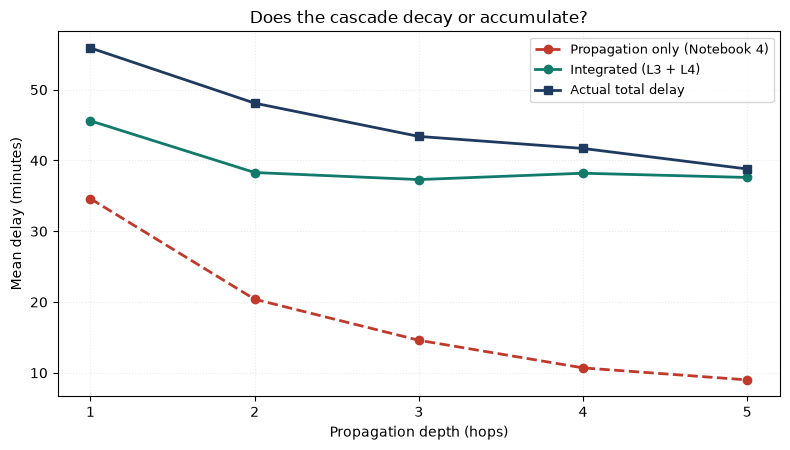

In [21]:
rows = []
for dpt in sorted(chain_new['depth'].unique()):
    o = chain_old[chain_old['depth'] == dpt]
    n = chain_new[chain_new['depth'] == dpt]
    rows.append({
        'depth': dpt,
        'n': len(n),
        'old_pred': round(o['pred_prop'].mean(), 1),
        'new_pred': round(n['pred_total'].mean(), 1),
        'actual_total': round(n['actual_total'].mean(), 1),
        'actual_inherited': round(n['actual_prop'].mean(), 1),
    })
decay = pd.DataFrame(rows)
print('=== MEAN DELAY BY DEPTH ===')
print(decay.to_string(index=False))
print()
print('old_pred     = propagation only (Notebook 4) — decayed with depth')
print('new_pred     = propagation + expected primary')
print('actual_total = what the flight actually was')

plt.figure(figsize=(8,4.6))
plt.plot(decay['depth'], decay['old_pred'], 'o--', color='#C0392B', lw=2,
         label='Propagation only (Notebook 4)')
plt.plot(decay['depth'], decay['new_pred'], 'o-', color='#117A6B', lw=2,
         label='Integrated (L3 + L4)')
plt.plot(decay['depth'], decay['actual_total'], 's-', color='#1F3A5F', lw=2,
         label='Actual total delay')
plt.xlabel('Propagation depth (hops)'); plt.ylabel('Mean delay (minutes)')
plt.title('Does the cascade decay or accumulate?')
plt.xticks(decay['depth']); plt.legend(fontsize=9); plt.grid(alpha=0.25, ls=':')
plt.tight_layout(); plt.show()

## 6 — Accuracy on total delay

The operationally meaningful question: how late will the flight be? Not the attribution split
between inherited and fresh, which only matters internally.

In [22]:
rows = []
for dpt in sorted(chain_new['depth'].unique()):
    o = chain_old[chain_old['depth'] == dpt]
    n = chain_new[chain_new['depth'] == dpt]
    rows.append({
        'depth': dpt,
        'n': len(n),
        'mae_old': round(mean_absolute_error(o['actual_total'], o['pred_prop']), 2),
        'mae_new': round(mean_absolute_error(n['actual_total'], n['pred_total']), 2),
        'corr_old': round(np.corrcoef(o['pred_prop'], o['actual_total'])[0,1], 3)
                     if o['pred_prop'].std() > 0 else np.nan,
        'corr_new': round(np.corrcoef(n['pred_total'], n['actual_total'])[0,1], 3)
                     if n['pred_total'].std() > 0 else np.nan,
    })
tot = pd.DataFrame(rows)
tot['improvement'] = (100*(tot['mae_old'] - tot['mae_new'])/tot['mae_old']).round(1)
print('=== MAE ON TOTAL DELAY ===')
print(tot.to_string(index=False))
print()
print('Positive improvement = integration helped.')

=== MAE ON TOTAL DELAY ===
 depth     n  mae_old  mae_new  corr_old  corr_new  improvement
     1 21999    23.25    20.87     0.672     0.674         10.2
     2 13167    36.37    31.88     0.451     0.428         12.3
     3  7234    42.55    35.15     0.405     0.327         17.4
     4  3421    49.62    38.66     0.273     0.233         22.1
     5  1377    54.84    39.91     0.254     0.226         27.2

Positive improvement = integration helped.


## 7 — Accuracy on the inherited component

Scored against `LATE_AIRCRAFT_DELAY`. The integration should not damage this — the propagated
component is predicted the same way; only the chained input changed.

In [23]:
rows = []
for dpt in sorted(chain_new['depth'].unique()):
    o = chain_old[chain_old['depth'] == dpt]
    n = chain_new[chain_new['depth'] == dpt]
    onz, nnz = o['actual_prop'] > 0, n['actual_prop'] > 0
    rows.append({
        'depth': dpt,
        'mae_prop_old': round(mean_absolute_error(
            o.loc[onz,'actual_prop'], o.loc[onz,'pred_prop']), 2) if onz.sum() else np.nan,
        'mae_prop_new': round(mean_absolute_error(
            n.loc[nnz,'actual_prop'], n.loc[nnz,'pred_prop']), 2) if nnz.sum() else np.nan,
        'n_cascades': int(nnz.sum()),
    })
print('=== MAE ON INHERITED COMPONENT (cascade cases) ===')
print(pd.DataFrame(rows).to_string(index=False))
print()
print('Notebook 4 depth-1 reference: 8.67 min')

=== MAE ON INHERITED COMPONENT (cascade cases) ===
 depth  mae_prop_old  mae_prop_new  n_cascades
     1          8.67          8.67       11194
     2         29.34         26.25        5499
     3         40.89         33.89        2704
     4         48.79         36.43        1177
     5         62.52         42.53         429

Notebook 4 depth-1 reference: 8.67 min


## 8 — Worked chains, before and after

In [24]:
deep = (chain_new.groupby(['ROT_ID','ORIGIN_LEG'])['depth'].max()
        .sort_values(ascending=False).head(80).index)
shown = 0
for rot, oleg in deep:
    n = chain_new[(chain_new['ROT_ID']==rot) & (chain_new['ORIGIN_LEG']==oleg)].sort_values('depth')
    o = chain_old[(chain_old['ROT_ID']==rot) & (chain_old['ORIGIN_LEG']==oleg)].sort_values('depth')
    if len(n) < 4 or n['actual_total'].max() < 30:
        continue
    seed = test[(test['ROT_ID']==rot) & (test['LEG_NUM']==oleg)].iloc[0]
    print(f"-- {seed['TAIL_NUM']}  {seed['FL_DATE'].date()}  ({seed['OP_UNIQUE_CARRIER']}) --")
    print(f"   ORIGIN leg {oleg}: {seed['ORIGIN']}->{seed['DEST']}  "
          f"arrived {seed['ARR_DELAY']:+.0f} min [observed]")
    t = n[['depth','LEG_NUM','ORIGIN','DEST','AVAILABLE_SLACK',
           'pred_prop','pred_primary','pred_total','actual_total']].copy()
    t = t.merge(o[['depth','pred_prop']].rename(columns={'pred_prop':'old_only'}),
                on='depth', how='left')
    t.columns = ['hop','leg','from','to','slack','inherit','fresh','TOTAL','actual','old']
    for c in ['slack','inherit','fresh','TOTAL','actual','old']:
        t[c] = t[c].round(0)
    print(t[['hop','leg','from','to','slack','old','inherit','fresh','TOTAL','actual']].to_string(index=False))
    print()
    shown += 1
    if shown >= 4:
        break

-- N782SK  2025-07-21  (OO) --
   ORIGIN leg 3: RNO->SFO  arrived +61 min [observed]
 hop  leg from  to  slack  old  inherit  fresh  TOTAL  actual
   1    4  SFO BUR   54.0  0.0      0.0   23.0   12.0    23.0
   2    5  BUR SFO   16.0  NaN      0.0   25.0   13.0    13.0
   3    6  SFO FAT   22.0  NaN      0.0   28.0   14.0    18.0
   4    7  FAT SFO   16.0  NaN      0.0   25.0   13.0    55.0
   5    8  SFO EUG   30.0  NaN      0.0   23.0   12.0    67.0

-- 206NV  2025-07-27  (G4) --
   ORIGIN leg 1: FLL->BNA  arrived +31 min [observed]
 hop  leg from  to  slack  old  inherit  fresh  TOTAL  actual
   1    2  BNA FLL   15.0 25.0     25.0   19.0   35.0    25.0
   2    3  FLL LCK   10.0 23.0     39.0   20.0   49.0    19.0
   3    4  LCK FLL   10.0 21.0     46.0   21.0   57.0    99.0
   4    5  FLL CAE   15.0 15.0     52.0   23.0   64.0    80.0
   5    6  CAE FLL   15.0 11.0     56.0   26.0   69.0   108.0

-- N782SK  2025-07-22  (OO) --
   ORIGIN leg 2: SFO->BUR  arrived +20 min [observed]


## 9 — Save

In [25]:
chain_new.to_parquet('results/layer4/cascade_chains_integrated.parquet', index=False)
tot.to_csv('results/layer4/integration_comparison.csv', index=False)
decay.to_csv('results/layer4/decay_comparison.csv', index=False)

summary = {
    'cascade_origins': int(len(origins)),
    'predictions': int(len(chain_new)),
    'global_primary_delay_min': round(float(GLOBAL_PRIMARY), 2),
    'recovery_rate': round(RECOVERY_RATE, 3),
    'mae_total_by_depth_old': tot['mae_old'].tolist(),
    'mae_total_by_depth_new': tot['mae_new'].tolist(),
    'improvement_pct_by_depth': tot['improvement'].tolist(),
}
with open('results/layer4/integration_summary.json','w') as f:
    json.dump(summary, f, indent=2)
print(json.dumps(summary, indent=2))
print()
print('Saved. Layers 3 and 4 now run as one system.')

{
  "cascade_origins": 22924,
  "predictions": 47198,
  "global_primary_delay_min": 21.55,
  "recovery_rate": 0.895,
  "mae_total_by_depth_old": [
    23.25,
    36.37,
    42.55,
    49.62,
    54.84
  ],
  "mae_total_by_depth_new": [
    20.87,
    31.88,
    35.15,
    38.66,
    39.91
  ],
  "improvement_pct_by_depth": [
    10.2,
    12.3,
    17.4,
    22.1,
    27.2
  ]
}

Saved. Layers 3 and 4 now run as one system.


## 10 — Category mismatch check

In [26]:
# ===== CATEGORY MISMATCH DIAGNOSTIC =====
# Notebook 3 trained the models using cat_types built from its TRAINING split.
# Notebooks 4 and 5 rebuild cat_types from the FULL dataset, which has more
# categories. This checks whether that difference changes predictions.

dates_chk = np.sort(df['FL_DATE'].unique())
train_end_chk = dates_chk[int(len(dates_chk)*0.70)]
trn_df = df[df['FL_DATE'] <= train_end_chk]

print('Category counts:')
for c in CAT_COLS:
    trn_cats = sorted(trn_df[c].dropna().unique())
    full_cats = sorted(df[c].dropna().unique())
    extra = sorted(set(full_cats) - set(trn_cats))
    print(f'  {c:20} train={len(trn_cats):>4}  full={len(full_cats):>4}  '
          f'extra={len(extra)}  {extra[:6]}')

sample = test[test['CONTINUOUS_ROTATION'].fillna(False) &
              (test['PREV_ARR_DELAY'] > 0)].head(5000).copy()
print(f'\nSample rows: {len(sample):,}')

def build_X(rows, inbound, cat_source):
    f = rows.copy()
    f['PREV_ARR_DELAY'] = np.asarray(inbound, dtype=float)
    f['SLACK_DEFICIT'] = f['PREV_ARR_DELAY'] - f['AVAILABLE_SLACK']
    f['DELAY_TO_SLACK_RATIO'] = (
        f['PREV_ARR_DELAY'] / f['AVAILABLE_SLACK'].clip(lower=1)).clip(upper=50)
    est = (f['PREV_ARR_DELAY'] - f['AVAILABLE_SLACK']).clip(lower=0)
    f['PROJECTED_ARR_HOUR'] = (((f['CRS_ARR_MIN'] + est) // 60) % 24).astype(int)
    f['PROJECTED_HOUR_ARRIVALS'] = pd.MultiIndex.from_arrays(
        [f['DEST'], f['FL_DATE'], f['PROJECTED_ARR_HOUR']]
    ).map(arr_counts).astype(float).fillna(0)
    f['ARRIVAL_CONGESTION_DELTA'] = f['PROJECTED_HOUR_ARRIVALS'] - f['DEST_HOUR_ARRIVALS']
    X = f[PROP_FEATURES].copy()
    for c in CAT_COLS:
        X[c] = X[c].astype(pd.CategoricalDtype(
            categories=sorted(cat_source[c].dropna().unique())))
    return X

X_train_cats = build_X(sample, sample['PREV_ARR_DELAY'].values, trn_df)
X_full_cats  = build_X(sample, sample['PREV_ARR_DELAY'].values, df)

p_a = gate.predict_proba(X_train_cats)[:, 1]
p_b = gate.predict_proba(X_full_cats)[:, 1]
m_a = mag['median'].predict(X_train_cats)
m_b = mag['median'].predict(X_full_cats)

print()
print('=== GATE PROBABILITY ===')
print(f'  Max abs difference : {np.abs(p_a-p_b).max():.8f}')
print(f'  Mean abs difference: {np.abs(p_a-p_b).mean():.8f}')
print(f'  Rows differing >0.01: {(np.abs(p_a-p_b) > 0.01).sum():,}')
print()
print('=== MAGNITUDE PREDICTION (minutes) ===')
print(f'  Max abs difference : {np.abs(m_a-m_b).max():.6f}')
print(f'  Mean abs difference: {np.abs(m_a-m_b).mean():.6f}')
print()
if np.abs(p_a-p_b).max() < 1e-6 and np.abs(m_a-m_b).max() < 1e-4:
    print('SAFE — category mismatch has no measurable effect.')
    print('All notebook 4 and 5 numbers stand. Document as a known non-issue.')
else:
    print('PROBLEM — predictions differ between category sets.')
    print('Notebook 4 and 5 results were computed through a mismatch and need recomputation.')

Category counts:
  OP_UNIQUE_CARRIER    train=  14  full=  14  extra=0  []
  ORIGIN               train= 345  full= 345  extra=0  []
  DEST                 train= 345  full= 345  extra=0  []

Sample rows: 5,000

=== GATE PROBABILITY ===
  Max abs difference : 0.00000000
  Mean abs difference: 0.00000000
  Rows differing >0.01: 0

=== MAGNITUDE PREDICTION (minutes) ===
  Max abs difference : 0.000000
  Mean abs difference: 0.000000

SAFE — category mismatch has no measurable effect.
All notebook 4 and 5 numbers stand. Document as a known non-issue.
